In [4]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ML Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve


In [5]:
data = pd.read_csv("train (1).csv")
print(data.shape)
data.head()


(800, 22)


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [6]:
data.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [8]:
data.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


📊 Exploratory Data Analysis (EDA)

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
g_labels = ['Male', 'Female']
c_labels = ['No', 'Yes']
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels, values=data['gender'].value_counts(), name="Gender"),
              1, 1)
fig.add_trace(go.Pie(labels=c_labels, values=data['Class/ASD'].value_counts(), name="Class/ASD"),
              1, 2)


fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)

fig.update_layout(
    title_text="Gender and Class/ASD Distributions",

    annotations=[dict(text='Gender', x=0.19, y=0.5, font_size=20, showarrow=False),
                 dict(text='Class/ASD', x=0.82, y=0.5, font_size=18, showarrow=False)])
fig.show()


#The distribution between males and females is similar, but the response rate with ASD varies by gender.

#The ASD category is unevenly distributed → There is a possibility of an imbalance problem.

The distribution between males and females is similar, but the response rate with ASD varies by gender.

The ASD category is unevenly distributed → There is a possibility of an imbalance problem.

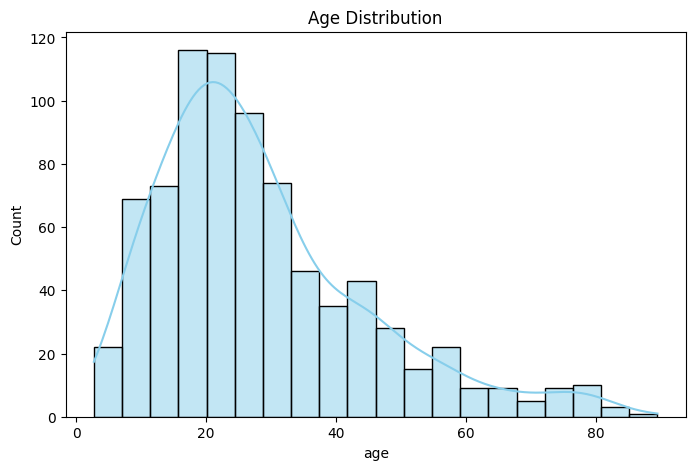

In [10]:

import plotly.express as px

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(data['age'], kde=True, bins=20, color="skyblue")
plt.title("Age Distribution")
plt.show()


Most cases occur in the young age group (10–20 years).

Age may still be an important prognostic feature.

In [11]:

# Gender distribution
fig = px.histogram(data, x="gender", color="Class/ASD", barmode="group",
                   title="Gender Distribution by ASD Class")
fig.show()


Insight : The dataset is slightly imbalanced in gender distribution, with more males than females

D:\Temp\ipykernel_11248\694007179.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




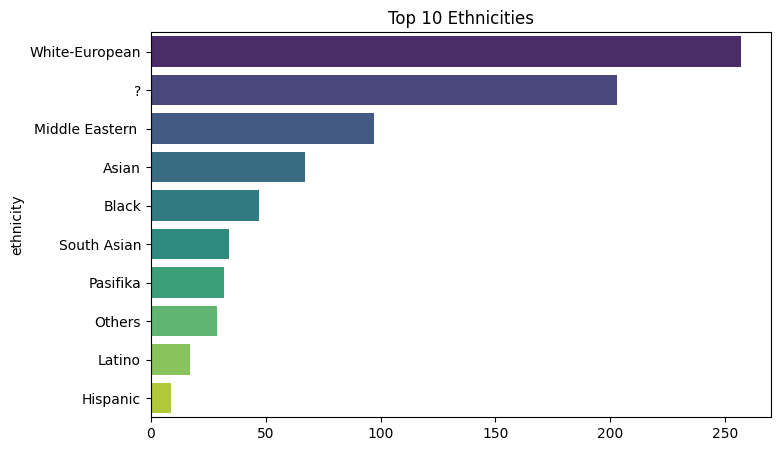

In [12]:


# Ethnicity distribution
ethnicity_count = data['ethnicity'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=ethnicity_count.values, y=ethnicity_count.index, palette="viridis")
plt.title("Top 10 Ethnicities")
plt.show()

Insight : The majority of samples belong to one or two dominant ethnic groups, which may bias the model

In [13]:

# Country of residence
fig = px.choropleth(data, locations="contry_of_res", locationmode="country names",
                    color="Class/ASD", title="ASD Cases by Country")
fig.show()


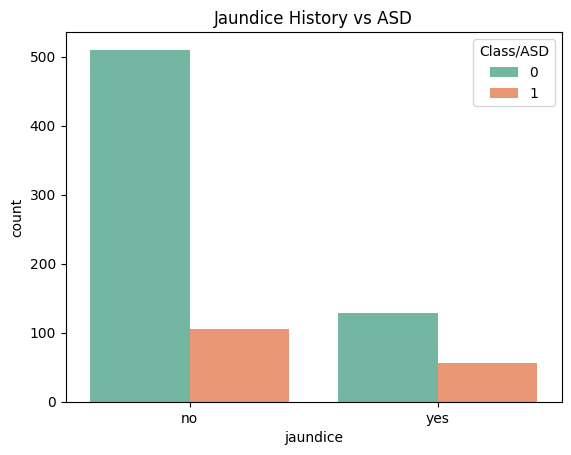

In [14]:

# Jaundice
sns.countplot(x="jaundice", hue="Class/ASD", data=data, palette="Set2")
plt.title("Jaundice History vs ASD")
plt.show()

Insight : Only a small portion of individuals report jaundice, showing class imbalance in this feature


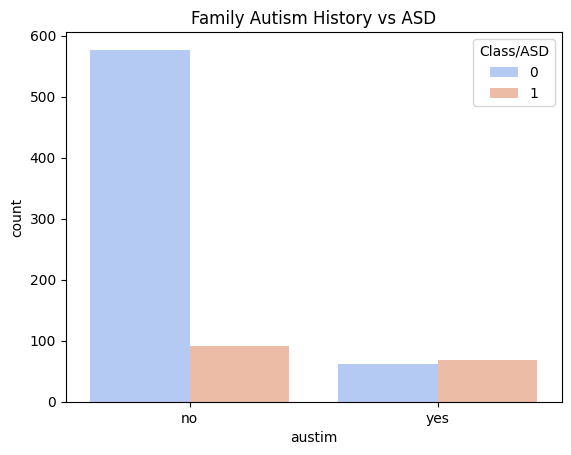

In [15]:

# Autism in family
sns.countplot(x="austim", hue="Class/ASD", data=data, palette="coolwarm")
plt.title("Family Autism History vs ASD")
plt.show()

Insight : The majority of participants report no family history of autism, suggesting this is a less common trait in the dataset


In [16]:


# Used app before
fig = px.pie(data, names="used_app_before", title="Used App Before Distribution")
fig.show()


D:\Temp\ipykernel_11248\3487680056.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




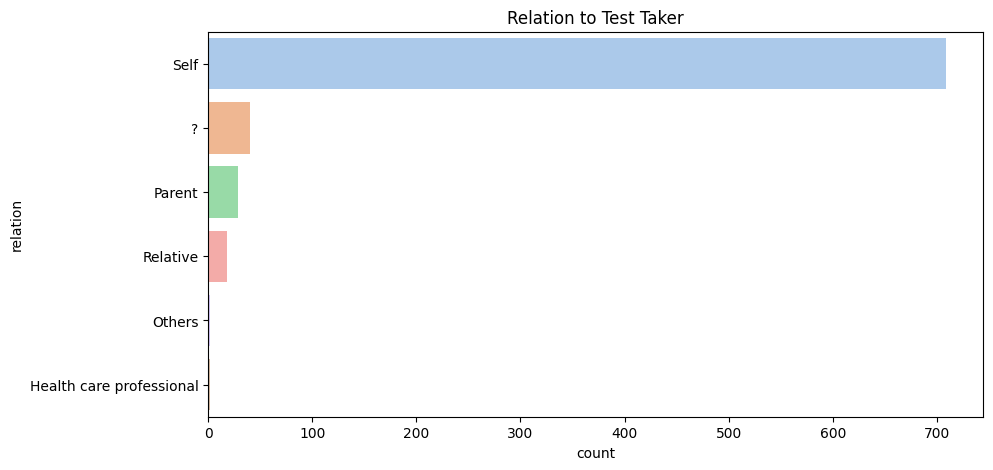

In [17]:

# Relation
plt.figure(figsize=(10,5))
sns.countplot(y="relation", data=data, order=data['relation'].value_counts().index, palette="pastel")
plt.title("Relation to Test Taker")
plt.show()

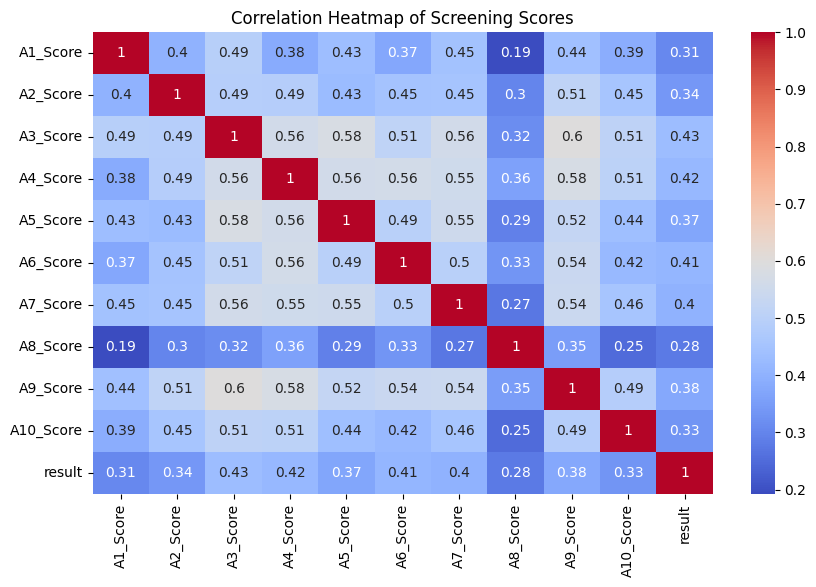

In [18]:


score_cols = [f"A{i}_Score" for i in range(1,11)]

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data[score_cols + ['result']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Screening Scores")
plt.show()


Insight Screening scores (A1–A10) are strongly correlated, confirming they capture similar behavioral patterns


In [19]:

# Radar chart (avg per class)
import plotly.graph_objects as go
avg_scores = data.groupby("Class/ASD")[score_cols].mean().T
fig = go.Figure()
for label in avg_scores.columns:
    fig.add_trace(go.Scatterpolar(r=avg_scores[label].values,
                                  theta=avg_scores.index,
                                  fill="toself", name=label))
fig.update_layout(title="Average Screening Scores by ASD Class",
                  polar=dict(radialaxis=dict(visible=True)))
fig.show()


D:\Temp\ipykernel_11248\158796208.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




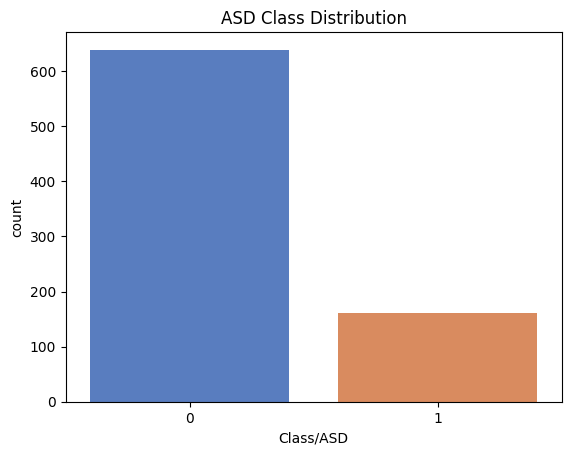

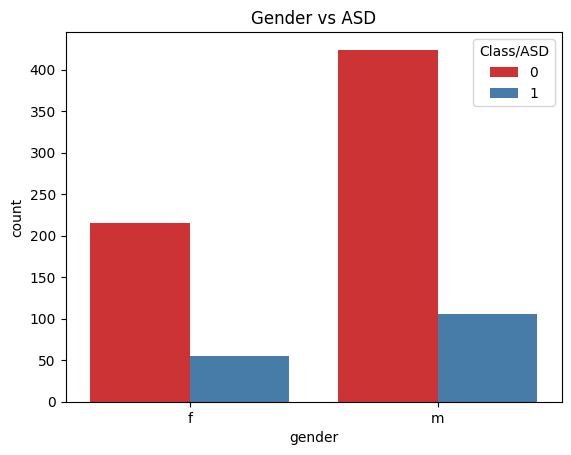

D:\Temp\ipykernel_11248\158796208.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




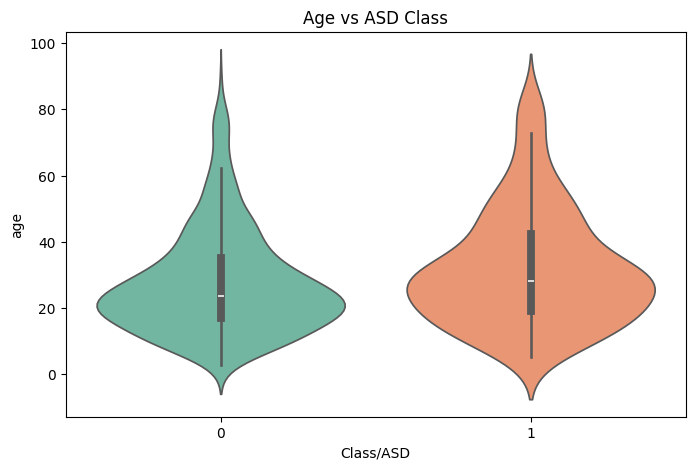

In [20]:





# Class distribution
sns.countplot(x="Class/ASD", data=data, palette="muted")
plt.title("ASD Class Distribution")
plt.show()

# Gender × Class
sns.countplot(x="gender", hue="Class/ASD", data=data, palette="Set1")
plt.title("Gender vs ASD")
plt.show()

# Age × Class
plt.figure(figsize=(8,5))
sns.violinplot(x="Class/ASD", y="age", data=data, palette="Set2")
plt.title("Age vs ASD Class")
plt.show()

# Sunburst
fig = px.sunburst(data, path=["gender","ethnicity","Class/ASD"],
                  title="ASD Distribution by Gender & Ethnicity")
fig.show()


Data PreProcessing

In [21]:
data=data.drop(["ID"] , axis=1)

In [22]:
data["gender"] = data["gender"].replace({"f": 0, "m": 1})

D:\Temp\ipykernel_11248\6433206.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [23]:
data = pd.get_dummies(data, columns=['ethnicity','jaundice',
       'austim', 'contry_of_res', 'used_app_before', 'age_desc',
       'relation'] , dtype=int)

In [24]:
data.dtypes

A1_Score                             int64
A2_Score                             int64
A3_Score                             int64
A4_Score                             int64
A5_Score                             int64
                                     ...  
relation_Health care professional    int64
relation_Others                      int64
relation_Parent                      int64
relation_Relative                    int64
relation_Self                        int64
Length: 95, dtype: object

In [25]:
y=data["Class/ASD"]
x=data.drop(["Class/ASD"] , axis=1)

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)


In [27]:
x_train , x_test , y_train , y_test =train_test_split(x ,y , test_size=0.3,random_state=42 , stratify=y)
print(x_train.shape , y_train.shape) , x_test , y_test

(560, 94) (560,)


(None,
 array([[-1.12815215,  0.94169658,  1.1055416 , ..., -0.19394197,
         -0.15171652,  0.35825939],
        [-1.12815215, -1.06191317, -0.90453403, ..., -0.19394197,
         -0.15171652,  0.35825939],
        [-1.12815215,  0.94169658,  1.1055416 , ..., -0.19394197,
         -0.15171652,  0.35825939],
        ...,
        [ 0.88640526,  0.94169658,  1.1055416 , ..., -0.19394197,
         -0.15171652,  0.35825939],
        [ 0.88640526, -1.06191317, -0.90453403, ..., -0.19394197,
         -0.15171652,  0.35825939],
        [-1.12815215, -1.06191317, -0.90453403, ..., -0.19394197,
         -0.15171652,  0.35825939]], shape=(240, 94)),
 446    0
 74     0
 466    0
 264    1
 298    0
       ..
 752    0
 777    0
 129    0
 618    0
 24     0
 Name: Class/ASD, Length: 240, dtype: int64)


RandomForestClassifier
RandomForestClassifier - Best Params: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
RandomForestClassifier - Accuracy Score: 0.8458


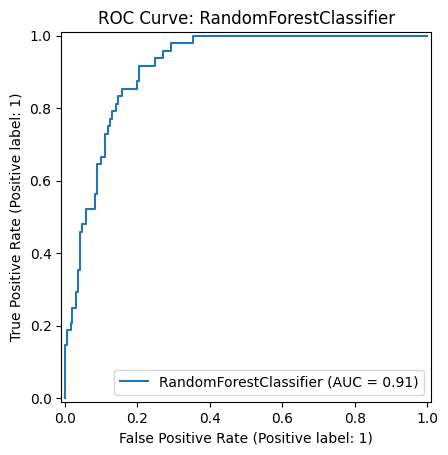

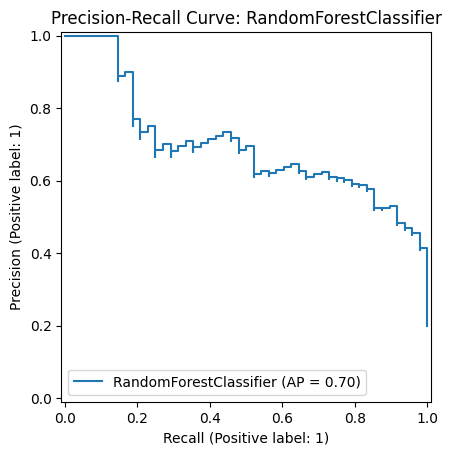

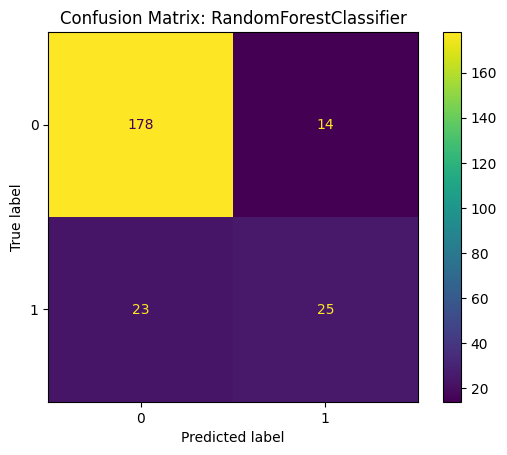


GradientBoostingClassifier
GradientBoostingClassifier - Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
GradientBoostingClassifier - Accuracy Score: 0.8583


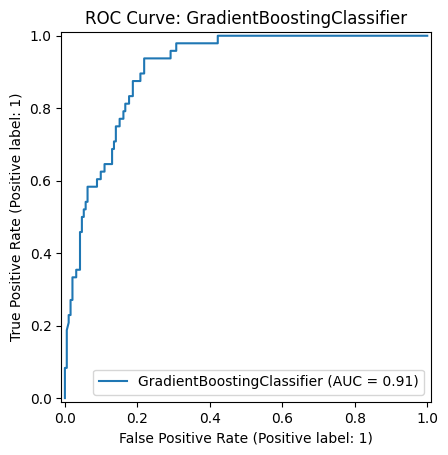

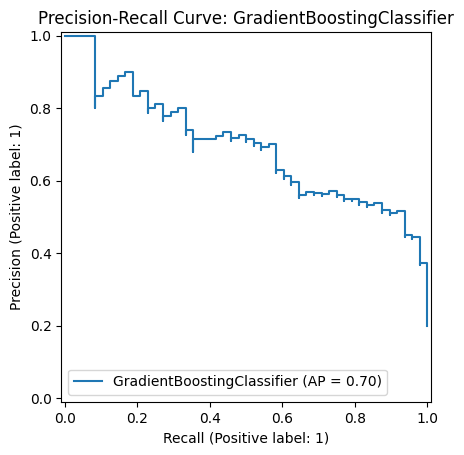

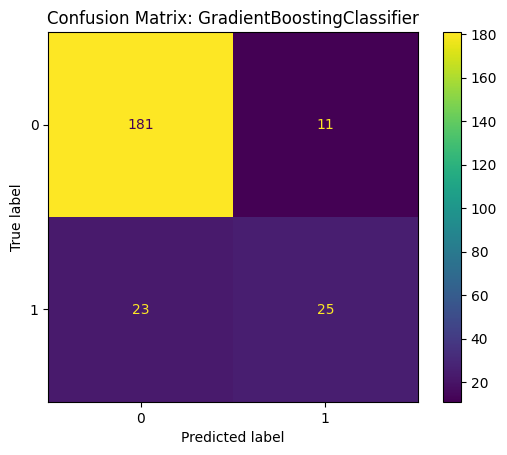


LogisticRegression


d:\python for data science\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

d:\python for data science\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

d:\python for data science\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

d:\python for data science\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

d:\python for data science\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

d:\python for data science\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means th

LogisticRegression - Best Params: {'C': 0.1, 'max_iter': 200, 'penalty': 'l1', 'solver': 'liblinear'}
LogisticRegression - Accuracy Score: 0.8667


d:\python for data science\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



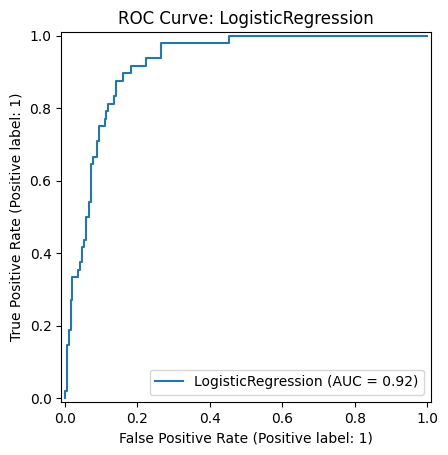

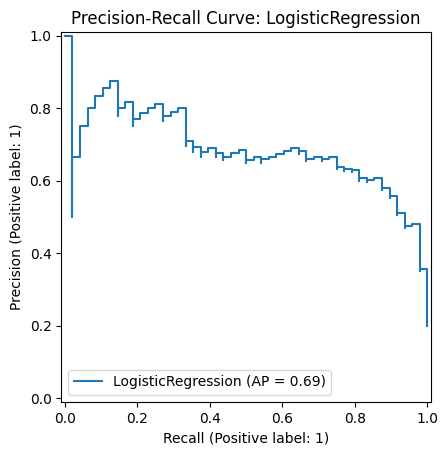

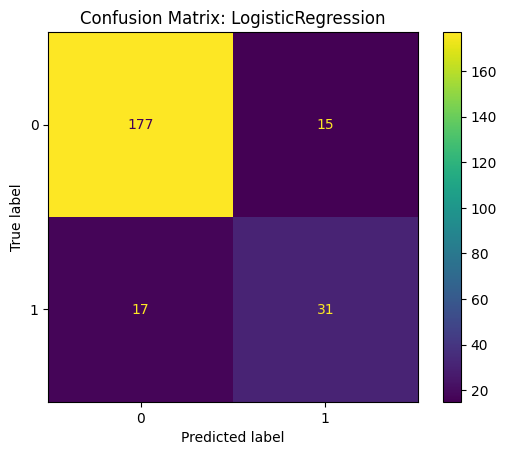


XGBClassifier


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:20] WARNING

XGBClassifier - Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
XGBClassifier - Accuracy Score: 0.8458


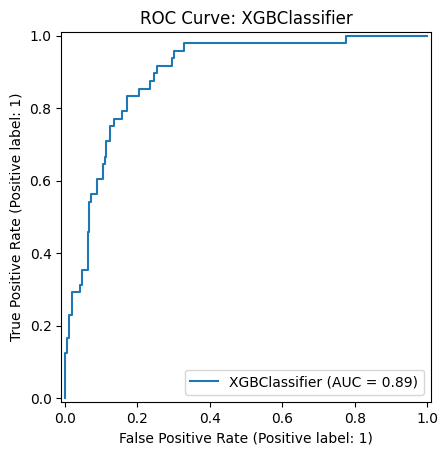

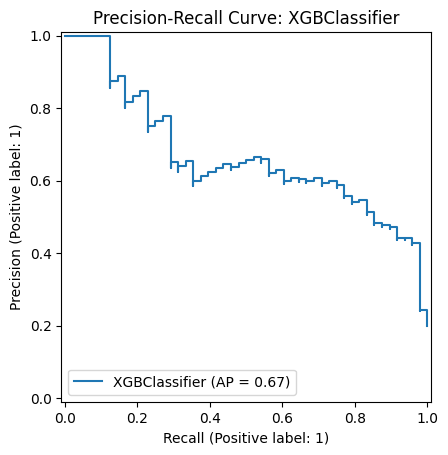

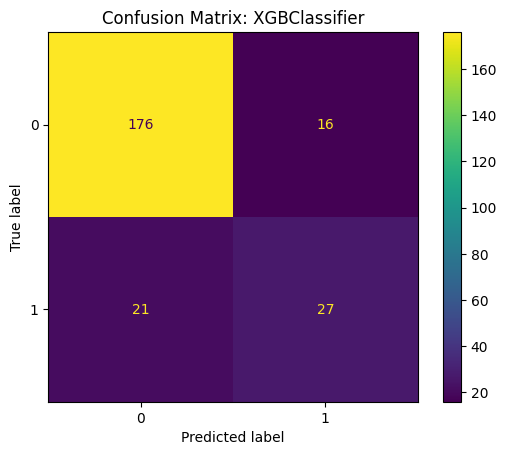


SVC
SVC - Best Params: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
SVC - Accuracy Score: 0.8625


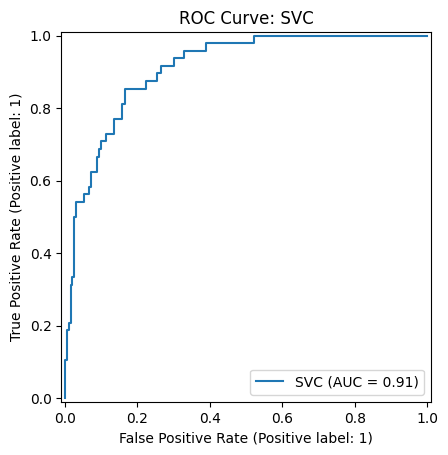

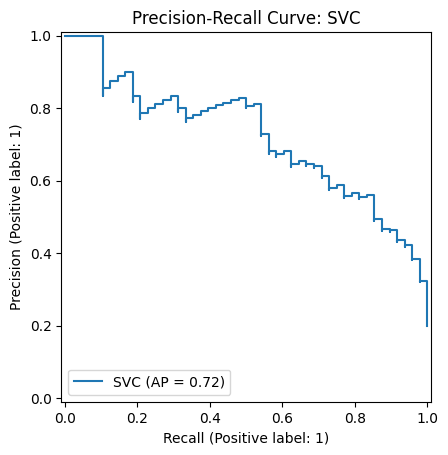

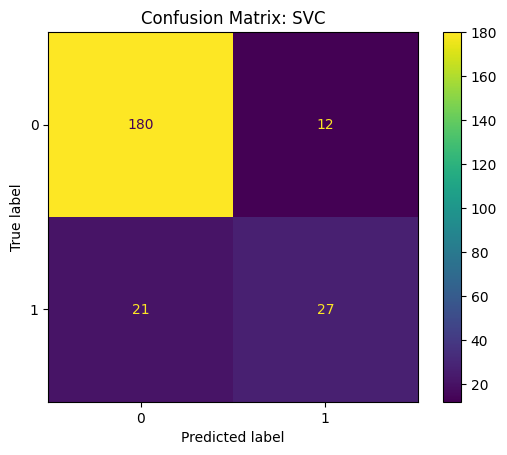

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


modeles = {
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=500),
    "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "SVC": SVC(probability=True) 
}


parameters = {
    "RandomForestClassifier": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    },
    "GradientBoostingClassifier": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0]
    },
    "LogisticRegression": {
        "penalty": ["l1", "l2"],
        "C": [0.1, 1, 10],
        "solver": ["liblinear", "saga"],
        "max_iter": [200, 500]
    },
    "XGBClassifier": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "SVC": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    }
}

# Training + Evaluation
for name, model in modeles.items():
    print(f"\n{name}")

   
    grid = GridSearchCV(model, parameters[name], cv=3, scoring="accuracy", n_jobs=1)
    grid.fit(x_train, y_train)

    best_model = grid.best_estimator_
    y_pre = best_model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pre)
    print(f"{name} - Best Params: {grid.best_params_}")
    print(f"{name} - Accuracy Score: {accuracy:.4f}")

    # Visualizations
    RocCurveDisplay.from_estimator(best_model, x_test, y_test)
    plt.title(f"ROC Curve: {name}")
    plt.show()

    PrecisionRecallDisplay.from_estimator(best_model, x_test, y_test)
    plt.title(f"Precision-Recall Curve: {name}")
    plt.show()

    ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()


RandomForestClassifier CV F1 mean: 0.738 ± 0.028
RandomForestClassifier Test Accuracy: 0.838
GradientBoostingClassifier CV F1 mean: 0.760 ± 0.017
GradientBoostingClassifier Test Accuracy: 0.858
LogisticRegression CV F1 mean: 0.743 ± 0.035
LogisticRegression Test Accuracy: 0.863


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:38] WARNING

XGBClassifier CV F1 mean: 0.727 ± 0.043
XGBClassifier Test Accuracy: 0.842
SVC CV F1 mean: 0.754 ± 0.022
SVC Test Accuracy: 0.867


D:\Temp\ipykernel_11248\2101000185.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




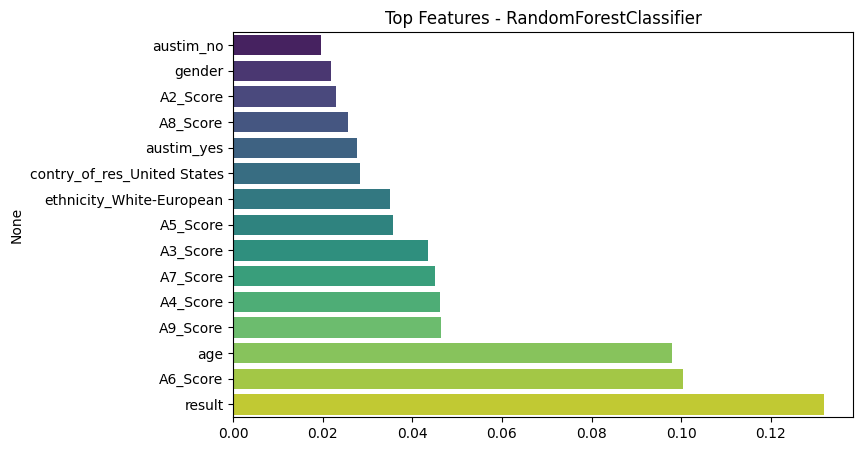

D:\Temp\ipykernel_11248\2101000185.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




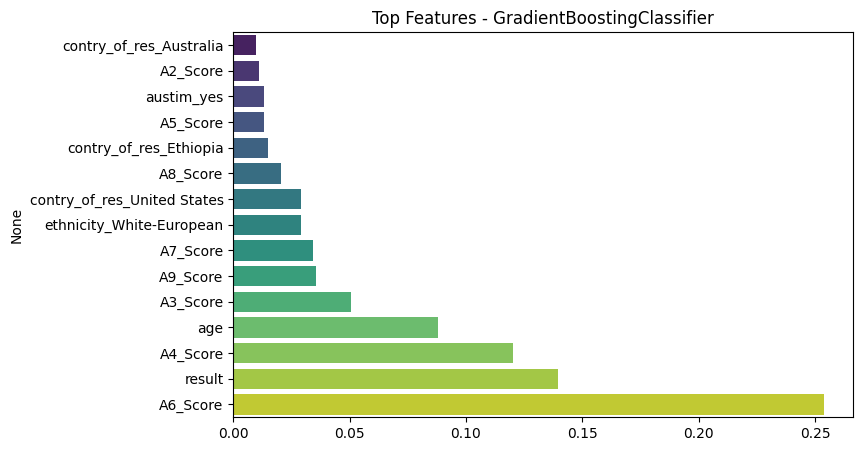

D:\Temp\ipykernel_11248\2101000185.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




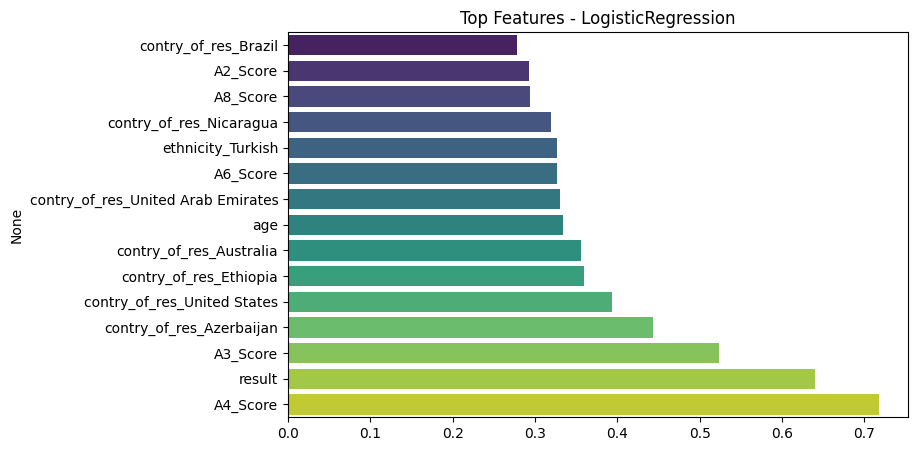

D:\Temp\ipykernel_11248\2101000185.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




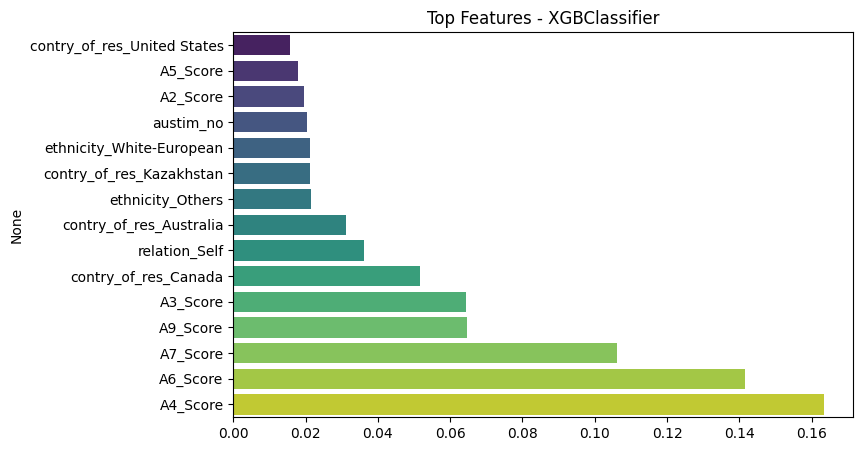

Best model saved: SVC(probability=True)


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
importances_dict = {}
best_model = None
best_score = 0

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in modeles.items():
    # Cross-validation (F1 macro)
    cv_scores = cross_val_score(model, x, y, cv=cv, scoring="f1_macro")
    print(f"{name} CV F1 mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    # Train on full train data
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Test Accuracy: {acc:.3f}")

    # Track best model
    if acc > best_score:
        best_score = acc
        best_model = model

    # Feature importance (if available)
    if hasattr(model, "feature_importances_"):
        importances_dict[name] = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances_dict[name] = np.abs(model.coef_[0])


#  Feature Importance Plots

feature_names = data.drop("Class/ASD", axis=1).columns

for name, imp in importances_dict.items():
    sorted_idx = np.argsort(imp)[-15:]  
    plt.figure(figsize=(8,5))
    sns.barplot(x=imp[sorted_idx], y=feature_names[sorted_idx], palette="viridis")
    plt.title(f"Top Features - {name}")
    plt.show()







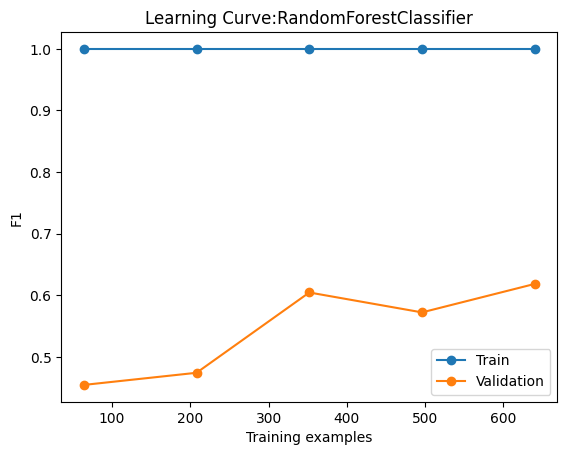

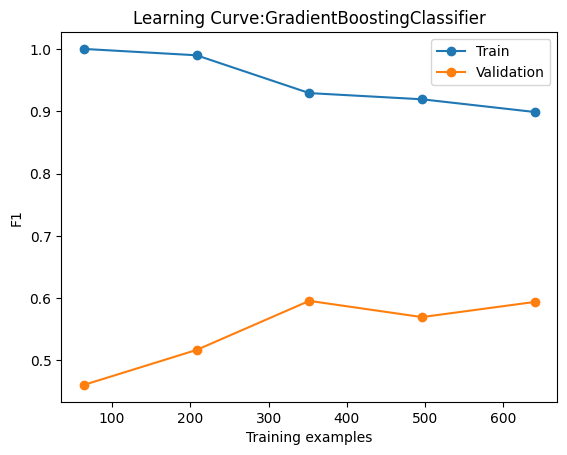

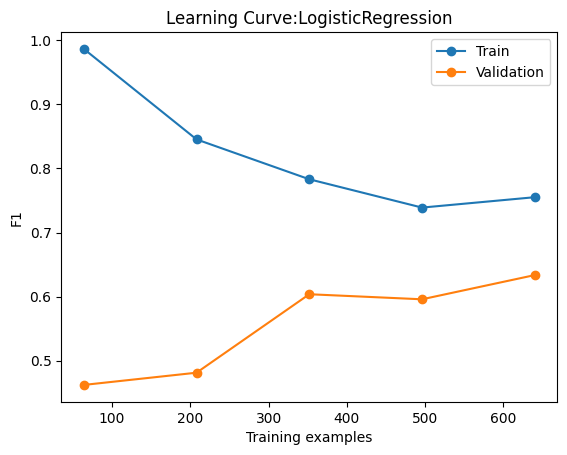

d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:51] WARNING

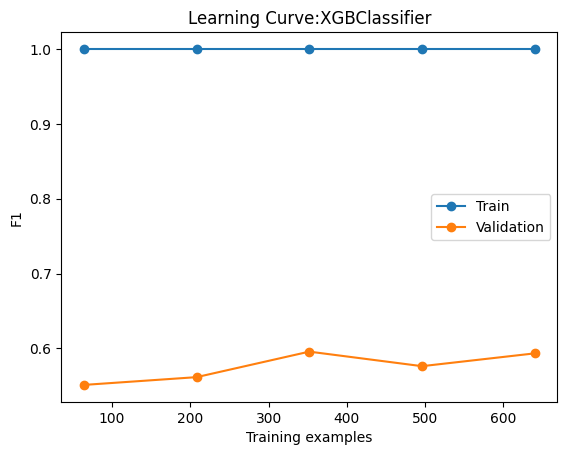

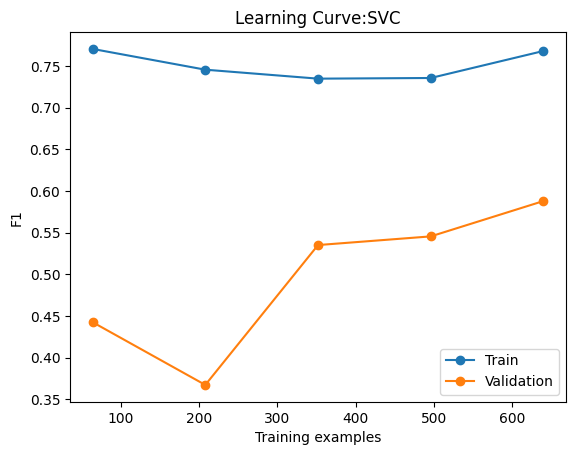

In [30]:
for name,a in modeles.items():
    train_sizes, train_scores, val_scores = learning_curve(
        a, x, y, cv=5, scoring='f1', train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=1)
    plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train')
    plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='Validation')
    plt.xlabel('Training examples'); plt.ylabel('F1'); plt.title(f'Learning Curve:{name}'); plt.legend(); plt.show()

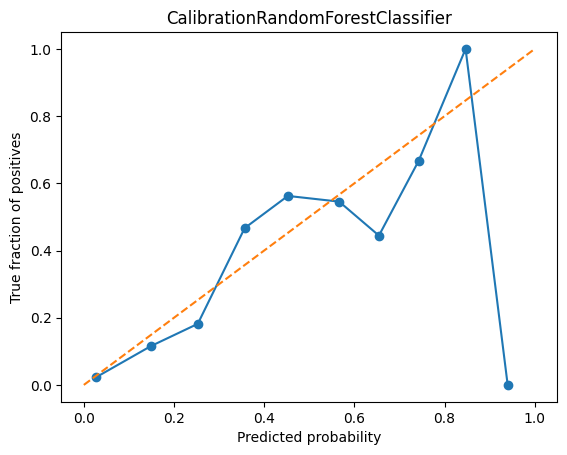

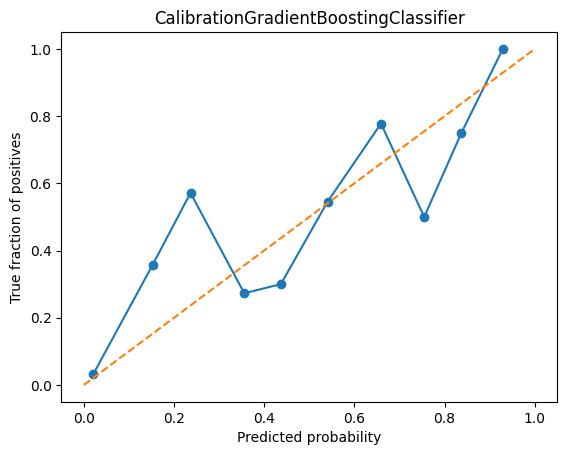

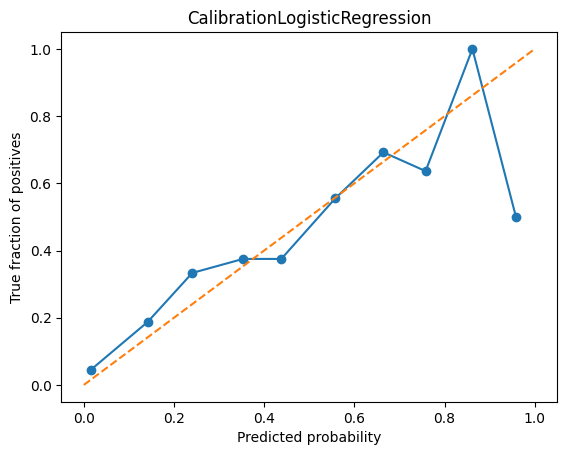

d:\python for data science\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[23:31:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




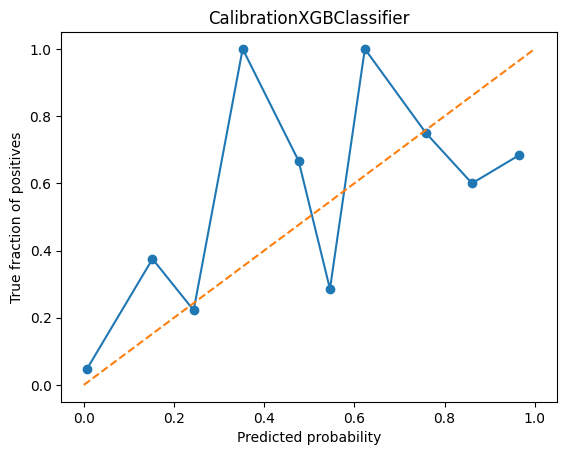

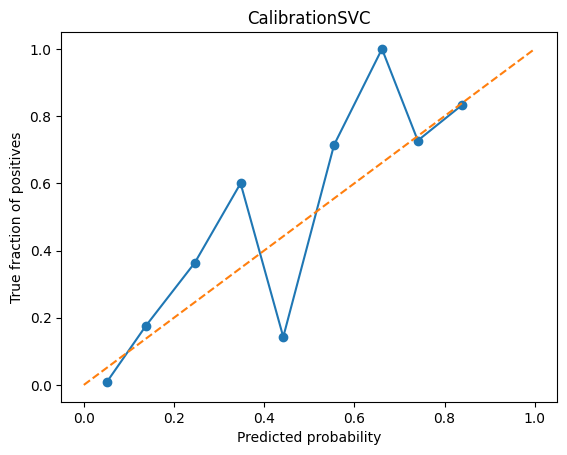

In [31]:
from sklearn.calibration import calibration_curve
# Calibration Curve
for name,a in modeles.items():
    a.fit(x_train, y_train)
    prob_pos = a.predict_proba(x_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, prob_pos, n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o'); plt.plot([0,1],[0,1],'--')
    plt.xlabel('Predicted probability'); plt.ylabel('True fraction of positives'); plt.title(f'Calibration{name}'); plt.show()

DeepLearning

In [32]:
import tensorflow as tf
from tensorflow import keras
from sklearn import metrics
model1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[94]),
    
    tf.keras.layers.Dense(64, activation=tf.nn.leaky_relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Dense(1, activation=tf.nn.sigmoid)
])
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         6,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,297 (59.75 KB)

 Trainable params: 14,913 (58.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [33]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

model1.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

hist = model1.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, lr_schedule]
)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5837 - loss: 0.9808 - val_accuracy: 0.5982 - val_loss: 0.7329 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7072 - loss: 0.6925 - val_accuracy: 0.7589 - val_loss: 0.5996 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7963 - loss: 0.5225 - val_accuracy: 0.7857 - val_loss: 0.5159 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7766 - loss: 0.5479 - val_accuracy: 0.8214 - val_loss: 0.4686 - learning_rate: 0.0010
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7848 - loss: 0.5069 - val_accuracy: 0.8304 - val_loss: 0.4430 - learning_rate: 0.0010
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8092 - loss: 0.5081 - val_accuracy: 0.8482 - val_loss: 0.4230 - learning_rate: 0.0010
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8024 - loss: 0.4335 - val_accurac

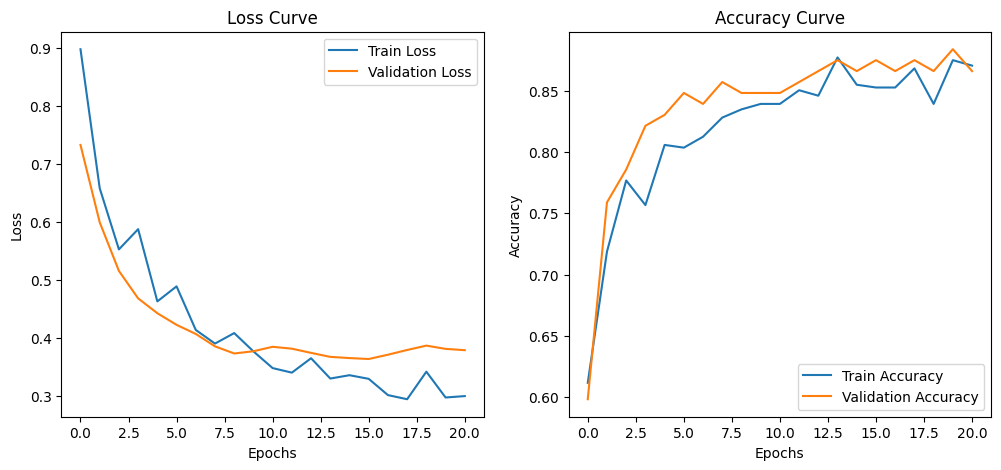

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(hist.history['loss'], label='Train Loss')
if 'val_loss' in hist.history:
    plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
if 'val_accuracy' in hist.history:
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()


In [35]:
test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f"📊 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")


📊 Test Accuracy: 0.8708
📉 Test Loss: 0.3259
